In [8]:
import os
print(os.listdir('dataset'))

['crop_part1', 'UTKFace', 'utkface_aligned_cropped']


In [24]:
"%pip install numpy pandas matplotlib scikit-learn tensorflow opencv-python kaggle"
import os
import cv2
import numpy as np

ruta = "dataset/UTKFace"

imagenes = []
edades = []

for archivo in os.listdir(ruta):
    try:
        if not archivo.endswith(".jpg"):
            continue

        edad = int(archivo.split("_")[0])

        img_path = os.path.join(ruta, archivo)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (128,128))

        imagenes.append(img)
        edades.append(edad)

    except:
        continue

X = np.array(imagenes)
y = np.array(edades)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

X = X[:5000]
y = y[:5000]

X = X.astype('float32')

Shape X: (23708, 128, 128, 3)
Shape y: (23708,)


In [25]:
X = X / 255.0

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [27]:
print(X_train[0].min(), X_train[0].max())

0.105882354 0.9137255


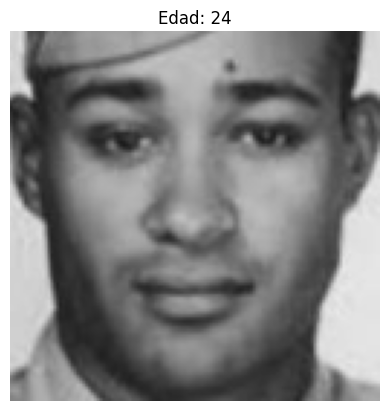

In [28]:
import matplotlib.pyplot as plt
import cv2

img = X_train[0]

# Convertir a formato visible
img = (img * 255).astype('uint8')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Edad: {y_train[0]}")
plt.axis('off')
plt.show()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)  # salida continua (edad)
])

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [15]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 454ms/step - loss: 152.7403 - mae: 8.8590 - val_loss: 119.4908 - val_mae: 7.3802
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 422ms/step - loss: 132.2171 - mae: 8.0914 - val_loss: 119.9006 - val_mae: 6.9188
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 407ms/step - loss: 125.9543 - mae: 7.6970 - val_loss: 120.5434 - val_mae: 7.1672
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 396ms/step - loss: 110.1406 - mae: 6.9225 - val_loss: 90.1760 - val_mae: 5.8120
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 389ms/step - loss: 104.3918 - mae: 6.3887 - val_loss: 84.4384 - val_mae: 5.5178
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 382ms/step - loss: 96.0182 - mae: 5.9347 - val_loss: 76.7754 - val_mae: 4.9351
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 375ms/step - loss: 91.7303 - mae: 5.7867 - val_loss: 75.3440 - val_mae: 4.9335
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 409ms/step - loss: 91.0735 - mae: 5.4755 - val_loss: 75.9805 - val_mae: 4.8492
Epoch 9/

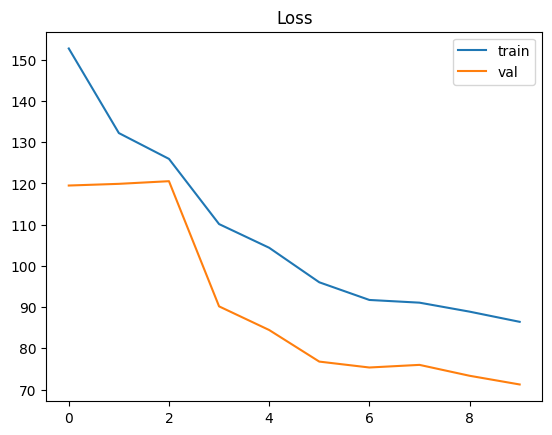

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step
MSE: 82.98682403564453
R2: 0.3472091555595398


In [18]:
import numpy as np

mae = np.mean(np.abs(y_test - y_pred))
print("MAE:", mae)

MAE: 8.907403051237106


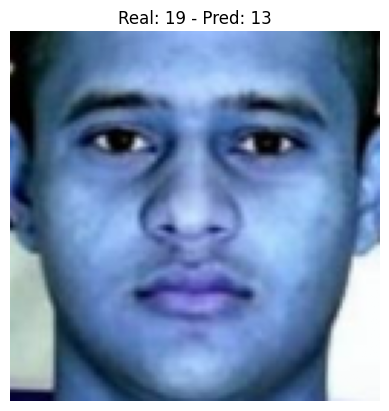

In [29]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0])
plt.title(f"Real: {y_test[0]} - Pred: {int(y_pred[0][0])}")
plt.axis('off')
plt.show()